# Úkol č. 1 - předzpracování dat a binární klasifikace

* Termíny jsou uvedeny na [courses.fit.cvut.cz/BI-ML1/homeworks/index.html](https://courses.fit.cvut.cz/BI-ML1/homeworks/index.html).
* Pokud odevzdáte úkol po prvním termínu ale před nejzazším termínem, budete penalizování -12 body, pozdější odevzdání je bez bodu.
* V rámci tohoto úkolu se musíte vypořádat s klasifikační úlohou s příznaky různých typů a s chybějícími hodnotami.
* Před tím, než na nich postavíte predikční model, je třeba je nějakým způsobem převést do číselné reprezentace.
    
> **Úkoly jsou zadány tak, aby Vám daly prostor pro invenci. Vymyslet _jak přesně_ budete úkol řešit, je důležitou součástí zadání a originalita či nápaditost bude také hodnocena!**

Využívejte buňky typu `Markdown` k vysvětlování Vašeho postupu. Za nepřehlednost budeme strhávat body.

## Zdroj dat

Budeme se zabývat predikcí přežití pasažérů Titaniku.
K dispozici máte trénovací data v souboru `data.csv` a data na vyhodnocení v souboru `evaluation.csv`.

#### Seznam příznaků:
* survived - zda pasažér přežil, 0 = Ne, 1 = Ano; **vysvětlovaná proměnná**, kterou chcete predikovat
* pclass - Třída lodního lístku, 1 = první, 2 = druhá, 3 = třetí
* name - jméno
* sex - pohlaví
* age - věk v letech
* sibsp	- počet sourozenců / manželů, manželek na palubě
* parch - počet rodičů / dětí na palubě
* ticket - číslo lodního lístku
* fare - cena lodního lístku
* cabin	- číslo kajuty
* embarked	- místo nalodění, C = Cherbourg, Q = Queenstown, S = Southampton
* home.dest - Bydliště/Cíl

## Pokyny k vypracování

**Body zadání**, za jejichž (poctivé) vypracování získáte **25 bodů**: 
  * V notebooku načtěte data ze souboru `data.csv`. Vhodným způsobem si je rozdělte na podmnožiny, které Vám poslouží pro trénování (trénovací), porovnávání modelů (validační) a následnou predikci výkonnosti finálního modelu (testovací).
    
  * Proveďte základní předzpracování dat:
    * Projděte si jednotlivé příznaky a transformujte je do vhodné podoby pro použití ve vybraném klasifikačním modelu.
    * Podle potřeby si můžete vytvářet nové příznaky (na základě existujících), například tedy můžete vytvořit příznak měřící délku jména atp.
    * Některé příznaky můžete také úplně zahodit.
    * Nějakým způsobem (klidně triviálním) se vypořádejte s chybějícími hodnotami. Není potřeba používat sofistikované metody. _Hlavně pozor na metodické chyby!_
    * Můžete využívat i vizualizace a vše stručně ale náležitě komentujte.

  
  * Na připravená data postupně aplikujte **rozhodovací strom** a **metodu nejbližších sousedů**, přičemž pro každý z těchto modelů:
    * Okomentujte vhodnost daného modelu pro daný typ úlohy.
    * Vyberte si hlavní hyperparametry k ladění a najděte jejich nejlepší hodnoty.
    * Pro model s nejlepšími hodnotami hyperparametrů spočtěte (na validační množině) F1 skóre, nakreslete ROC křivku a určete AUC. _Pozor na metodické chyby!_
    * Získané výsledky vždy řádně okomentujte.

        
  * Ze všech zkoušených možností v předchozím kroku vyberte finální model (jednoznačně popište o který konkrétně jde) a správně odhadněte, jakou **přesnost** můžete očekávat na nových datech, která jste doposud neměli k dispozici. _Pozor na metodické chyby!_
    
  * Nakonec načtěte vyhodnocovací data ze souboru `evaluation.csv`. Pomocí finálního modelu napočítejte predikce pro tyto data (vysvětlovaná proměnná v nich již není). Vytvořte soubor `results.csv`, ve kterém získané predikce uložíte do sloupce **survived** a identifikátory do sloupce **ID** (dodržte názvy sloupců!). Tento soubor též odevzdejte (uložte do repozitáře vedle notebooku).

      * Snažte se vše udělat tak, aby přesnost odevzdaných predikcí na vyhodocovacím datasetu byla alespoň **75%**. Pokud bude menší, přijdete o **3 body**.
      * Ukázka, jak by mělo vypadat prvních několik řádků souboru `results.csv` (obecně s jinými hodnotami survived):
  
```
ID,survived
1000,0
1001,1
...
```

## Poznámky k odevzdání

  * Řiďte se pokyny ze stránky https://courses.fit.cvut.cz/BI-ML1/homeworks/index.html.
  * Vytvořte i csv soubor `results.csv` s predikcemi a uložte ho v rámci projektu vedle ipython notebooku.

# Řešení 🎯

In [1]:
# imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv('data.csv')

ydata = data['survived']
Xdata = data.drop('survived', axis=1)

seed = 42
# rozdělujeme data na trénovací, validační a testovací, poměr 60:20:20
Xtrain, Xtest, ytrain, ytest = train_test_split(Xdata, ydata, test_size=0.20, random_state=seed) 
Xtrain, Xval, ytrain, yval = train_test_split(Xtrain, ytrain, test_size=0.25, random_state=seed)

## Předzpracování dat 🧹💨

Nejprve se podíváme na to, s jakými daty vlastně pracujeme.

Můžeme si všimnout chybějících hodnot v některých sloupcích a také nenumerických příznaků, které by mohly být problematické pro modely, které budeme chtít vytvářet.

In [3]:
Xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 600 entries, 876 to 482
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         600 non-null    int64  
 1   pclass     600 non-null    int64  
 2   name       600 non-null    object 
 3   sex        600 non-null    object 
 4   age        473 non-null    float64
 5   sibsp      600 non-null    int64  
 6   parch      600 non-null    int64  
 7   ticket     600 non-null    object 
 8   fare       600 non-null    float64
 9   cabin      128 non-null    object 
 10  embarked   600 non-null    object 
 11  home.dest  340 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 60.9+ KB


In [4]:
for column in Xtrain.columns:
    print(f"Top 15 most common values in '{column}':")
    print(Xtrain[column].value_counts().head(15))
    print("\n")

Top 15 most common values in 'ID':
ID
482    1
876    1
326    1
381    1
853    1
311    1
306    1
490    1
674    1
703    1
288    1
956    1
276    1
487    1
571    1
Name: count, dtype: int64


Top 15 most common values in 'pclass':
pclass
3    327
1    144
2    129
Name: count, dtype: int64


Top 15 most common values in 'name':
name
Warren, Mr. Charles William                                 1
Assaf, Mr. Gerios                                           1
Williams, Mr. Charles Duane                                 1
Arnold-Franchi, Mrs. Josef (Josefine Franchi)               1
Rothes, the Countess. of (Lucy Noel Martha Dyer-Edwards)    1
Brocklebank, Mr. William Alfred                             1
Vander Planke, Mr. Leo Edmondus                             1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)         1
Chambers, Mrs. Norman Campbell (Bertha Griggs)              1
Sutehall, Mr. Henry Jr                                      1
Mellors, Mr. William John           

Pokud se blíže podíváme na typické hodnoty, které nabývají sloupce v trénovacím datasetu, vidíme, že mnoho z těchto kategorických příznaků jsou nominální příznaky, které nabývají mnoha různých hodnot (name, ticket...).

Jelikož tedy dataset nijak významně nerozdělují na dostatečně velké podmnožiny, z nichž by se daly vyčíst general patterny pro predikce (mnoho nominálních hodnot, z nichž je každá nabyta omezeným počtem řádků), můžeme se těchto příznaků zbavit a získat tak přehlednější dataset pro vytváření modelů:

In [5]:
cols_to_drop = ['name', 'ticket', 'cabin', 'embarked', 'home.dest']

for df in [Xtest, Xval, Xtrain]:
    df.drop(cols_to_drop, axis=1, inplace=True)

Xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 600 entries, 876 to 482
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      600 non-null    int64  
 1   pclass  600 non-null    int64  
 2   sex     600 non-null    object 
 3   age     473 non-null    float64
 4   sibsp   600 non-null    int64  
 5   parch   600 non-null    int64  
 6   fare    600 non-null    float64
dtypes: float64(2), int64(4), object(1)
memory usage: 37.5+ KB


Jediný zbývající problematický příznak je tedy *sex*, který jak jsme ale již zjistili, nabývá pouze dvojice hodnot *male* a *female* a stačí z něj tedy vytvořit binární příznak, který nám bude říkat, zda je či není daná osoba ženou.

Poslední co nám zbývá je pak již jen ošetření chybějících hodnot, které jednoduše nastavíme na -1 a necháme modely, aby s nimi takto samy počítaly.

In [6]:
Xtrain['sex'] = Xtrain['sex'].map({'female': 1, 'male': 0})
Xval['sex'] = Xval['sex'].map({'female': 1, 'male': 0})
Xtest['sex'] = Xtest['sex'].map({'female': 1, 'male': 0})

for df in [Xtrain, Xval, Xtest]:
    df.fillna(-1, inplace=True)

display(Xtrain.info())
display(Xtrain.isnull().sum(axis=0))
display(Xval.isnull().sum(axis=0))
display(Xtest.isnull().sum(axis=0))

<class 'pandas.core.frame.DataFrame'>
Index: 600 entries, 876 to 482
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      600 non-null    int64  
 1   pclass  600 non-null    int64  
 2   sex     600 non-null    int64  
 3   age     600 non-null    float64
 4   sibsp   600 non-null    int64  
 5   parch   600 non-null    int64  
 6   fare    600 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 37.5 KB


None

ID        0
pclass    0
sex       0
age       0
sibsp     0
parch     0
fare      0
dtype: int64

ID        0
pclass    0
sex       0
age       0
sibsp     0
parch     0
fare      0
dtype: int64

ID        0
pclass    0
sex       0
age       0
sibsp     0
parch     0
fare      0
dtype: int64

Přípravu dat tak máme hotovou a můžeme se pustit do vytváření modelů samotných! 🙌

## Rozhodovací strom 🌳

Rozhodovací strom je vhodný pro tento typ problému, protože je schopný dobře odhalit nelineární vztahy mezi příznaky a jak jejich kombinace mohou ovlivnit šanci pasažérů na přežití. Má však tendenci k přeučení a musíme si proto dát pozor na vhodné zvolení hyperparamterů, které nebude příliš ovlivněné trénovacím datasetem (k tomu využijeme právě validační dataset). Zároveň mohou mít rozhodovací stromy problém s nevyváženými datasety, jako máme zde, kde počet mrtvých výrazně převyšuje počet přeživších.

DecisionTreeClassifier je zde obzvlášť vhodný, protože je vytvořen pro kategorické predikce (zde binární predikce, zda pasažér přežil či ne).

In [7]:
from sklearn.tree import DecisionTreeClassifier
import sklearn.metrics as metrics
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [8]:
# vybíráme si hyperparametry, které dobře preventují přeučení modelu
param_grid = {
    'max_depth': range(1,20), 
    'criterion': ['entropy', 'gini'],
    'max_features': range(1,7),
    'min_samples_leaf': range(1,25),
}
param_comb = ParameterGrid(param_grid)

In [9]:
# pro každou variantu hyperparametrů zjistíme, jak dobře si vede na trénovacím a validačním datasetu
val_acc = []
train_acc = []
for params in param_comb:
    clf = DecisionTreeClassifier(max_depth=params['max_depth'], criterion=params['criterion'], max_features=params['max_features'], min_samples_leaf=params['min_samples_leaf'], random_state = seed)
    clf.fit(Xtrain, ytrain)
    train_acc.append(metrics.accuracy_score(ytrain, clf.predict(Xtrain)))
    val_acc.append(metrics.accuracy_score(yval, clf.predict(Xval)))

In [10]:
# podle výsledků na validační množině vybereme nejlepší sadu hyperparametrů, s níž natrénujeme finální model
best_paramsT = param_comb[np.argmax(val_acc)]
print("Best hyperparameters for DecisionTreeClassifier:", best_paramsT)

final_clfT = DecisionTreeClassifier(**best_paramsT, random_state = seed)
final_clfT.fit(Xtrain, ytrain)
print('Accuracy score (train): {0:.6f}'.format(metrics.accuracy_score(ytrain, final_clfT.predict(Xtrain))))
print('Accuracy score (validation): {0:.6f}'.format(metrics.accuracy_score(yval, final_clfT.predict(Xval))))

Best hyperparameters for DecisionTreeClassifier: {'min_samples_leaf': 5, 'max_features': 3, 'max_depth': 5, 'criterion': 'entropy'}
Accuracy score (train): 0.800000
Accuracy score (validation): 0.835000


F1 score: 0.778523
AUC: 0.836280


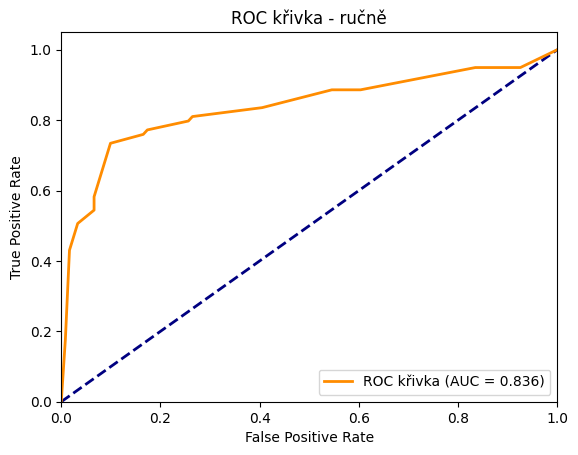

In [11]:
# vzhledem k tomu, že máme nevyvážený dataset, budeme při vybírání lepšího modelu brát v potaz i F1 skóre a ROC křivku
print('F1 score: {0:.6f}'.format(f1_score(yval, final_clfT.predict(Xval))))

yprobval = final_clfT.predict_proba(Xval)[:, 1]
fpr, tpr, thresholds = roc_curve(yval, yprobval)

AUC = auc(fpr, tpr)

print('AUC: {0:.6f}'.format(AUC))

plt.figure()
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.plot(fpr, tpr, color="darkorange", lw=2, label = f"ROC křivka (AUC = {AUC:.3f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC křivka - ručně")
plt.legend(loc="lower right")
plt.show()

## Metoda nejbližších sousedů 🚢

Metoda nejbližších sousedů přiřadí samplu predikovanou proměnou na základě hodnot trénovacích dat, které mu jsou nejblíže napříč všemi příznaky. KNN tak může dobře zachytit lokální patterny a vztahy, které by mohly ovlivňovat pravděpodobnost přežití jedince (například podobnost ve věku nebo třídě mezi přeživšími).

KNN však trpí prokletím dimenzionality - čím více máme příznaků, tím více máme dimenzí, což způsobí, že jednotlivá data se od sebe vzdalují a i nejbližší sousedi jednotlivých datových bodů jsou tak velmi vzdálení.

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

In [13]:
# zjistíme si, jaká normalizace má největší přesnost, a tu budeme nadále používat
clf = KNeighborsClassifier()
clf.fit(Xtrain, ytrain)

print(f"Validation accuracy (non-normalized model): {metrics.accuracy_score(yval, clf.predict(Xval)):0.4f}")

scaler = MinMaxScaler()
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xval_scaled = scaler.transform(Xval)

clf = KNeighborsClassifier()
clf.fit(Xtrain_scaled, ytrain)

print(f"Validation accuracy of normalized model (MinMaxscaler): {clf.score(Xval_scaled, yval):0.4f}")

scaler = StandardScaler()
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xval_scaled = scaler.transform(Xval)
Xtest_scaled = scaler.transform(Xtest)

clf = KNeighborsClassifier()
clf.fit(Xtrain_scaled, ytrain)

print(f"Validation accuracy of normalized model (StandardScaler): {clf.score(Xval_scaled, yval):0.4f}")

Validation accuracy (non-normalized model): 0.6300
Validation accuracy of normalized model (MinMaxscaler): 0.7400
Validation accuracy of normalized model (StandardScaler): 0.7850


In [14]:
# znovu budeme hledat hyperparametry, které mají největší přesnost na validační množině
param_grid = {
    'n_neighbors': range(1, 21),
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}
param_comb = ParameterGrid(param_grid)

In [15]:
val_acc = []
train_acc = []
for params in param_comb:
    clf = KNeighborsClassifier(n_neighbors=params['n_neighbors'], metric=params['metric'], weights=params['weights'], algorithm=params['algorithm'])
    clf.fit(Xtrain_scaled, ytrain)
    train_acc.append(metrics.accuracy_score(ytrain, clf.predict(Xtrain_scaled)))
    val_acc.append(metrics.accuracy_score(yval, clf.predict(Xval_scaled)))

In [16]:
# podle výsledků na validační množině vybereme nejlepší sadu hyperparametrů, s níž natrénujeme finální model
best_paramsK = param_comb[np.argmax(val_acc)]
print("Best hyperparameters for KNN:", best_paramsK)

final_clfK = KNeighborsClassifier(**best_paramsK)
final_clfK.fit(Xtrain_scaled, ytrain)
print('Accuracy score (train): {0:.6f}'.format(metrics.accuracy_score(ytrain, final_clfK.predict(Xtrain_scaled))))
print('Accuracy score (validation): {0:.6f}'.format(metrics.accuracy_score(yval, final_clfK.predict(Xval_scaled))))

Best hyperparameters for KNN: {'weights': 'uniform', 'n_neighbors': 12, 'metric': 'manhattan', 'algorithm': 'auto'}
Accuracy score (train): 0.813333
Accuracy score (validation): 0.815000


F1 score: 0.744828
AUC: 0.871796


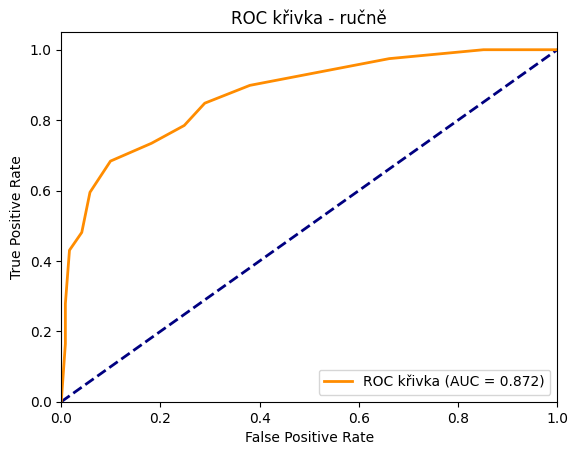

In [17]:
# a znovu si spočteme f1 skóre a nakreslíme ROC křivku
print('F1 score: {0:.6f}'.format(f1_score(yval, final_clfK.predict(Xval_scaled))))

yprobval = final_clfK.predict_proba(Xval_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(yval, yprobval)

AUC = auc(fpr, tpr)

print('AUC: {0:.6f}'.format(AUC))

plt.figure()
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.plot(fpr, tpr, color="darkorange", lw=2, label = f"ROC křivka (AUC = {AUC:.3f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC křivka - ručně")
plt.legend(loc="lower right")
plt.show()

## Výsledky 🏆

Přesnost obou výsledných modelů na validačním datasetu je velmi podobná (liší se o dvě procenta ve prospěch rozhodovacího stromu). Rozhodovací strom má zároveň i o něco lepší F1 skóre (něco přes tři procenta). KNN má však o něco vyšší plochu pod křivkou a zdá se být stabilnější, navíc není ovlivněn výběrem seedu, který může dále způsobit přeučení na konkrétní trénovací množině a vést k horším výsledkům na nových datech.

Jako finální model tak vybíráme KNN s níže uvedenými hyperparametry. Z testovacích dat pak dostáváme přesnost, kterou můžeme od tohoto modelu očekávat na nových datech - tedy něco okolo 82%.

In [18]:
print("Final KNN model hyperparameters:", best_paramsK)
print('Accuracy score (test): {0:.6f}'.format(metrics.accuracy_score(ytest, final_clfK.predict(Xtest_scaled))))

Final KNN model hyperparameters: {'weights': 'uniform', 'n_neighbors': 12, 'metric': 'manhattan', 'algorithm': 'auto'}
Accuracy score (test): 0.825000


Nakonec ještě využijeme finální model k predikci evaluation dat a máme hotovo. ✅

In [19]:
eval_data = pd.read_csv('evaluation.csv')

cols_to_drop = ['name', 'ticket', 'cabin', 'embarked', 'home.dest']
eval_data.drop(cols_to_drop, axis=1, inplace=True)

eval_data.fillna(-1, inplace=True)

eval_data['sex'] = eval_data['sex'].map({'female': 1, 'male': 0})

Xeval_scaled = scaler.transform(eval_data)

eval_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      309 non-null    int64  
 1   pclass  309 non-null    int64  
 2   sex     309 non-null    int64  
 3   age     309 non-null    float64
 4   sibsp   309 non-null    int64  
 5   parch   309 non-null    int64  
 6   fare    309 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 17.0 KB


In [20]:
predictions = final_clfK.predict(Xeval_scaled)

results = pd.DataFrame({'ID': eval_data['ID'], 'survived': predictions})
results.to_csv('results.csv', index=False)